In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [71]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch the dataset
mice_data = fetch_ucirepo(id=342)

# Features and target
X = mice_data.data.features
y = mice_data.data.targets

# Display shape and columns
print("Original shape:", X.shape)
print("Columns:", X.columns.tolist())

# Drop only the last 3 non-feature columns
X_filtered = X.iloc[:, :-3]
print("Corrected filtered shape:", X_filtered.shape)



Original shape: (1080, 80)
Columns: ['DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N', 'pJNK_N', 'PKCA_N', 'pMEK_N', 'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pPKCAB_N', 'pRSK_N', 'AKT_N', 'BRAF_N', 'CAMKII_N', 'CREB_N', 'ELK_N', 'ERK_N', 'GSK3B_N', 'JNK_N', 'MEK_N', 'TRKA_N', 'RSK_N', 'APP_N', 'Bcatenin_N', 'SOD1_N', 'MTOR_N', 'P38_N', 'pMTOR_N', 'DSCR1_N', 'AMPKA_N', 'NR2B_N', 'pNUMB_N', 'RAPTOR_N', 'TIAM1_N', 'pP70S6_N', 'NUMB_N', 'P70S6_N', 'pGSK3B_N', 'pPKCG_N', 'CDK5_N', 'S6_N', 'ADARB1_N', 'AcetylH3K9_N', 'RRP1_N', 'BAX_N', 'ARC_N', 'ERBB4_N', 'nNOS_N', 'Tau_N', 'GFAP_N', 'GluR3_N', 'GluR4_N', 'IL1B_N', 'P3525_N', 'pCASP9_N', 'PSD95_N', 'SNCA_N', 'Ubiquitin_N', 'pGSK3B_Tyr216_N', 'SHH_N', 'BAD_N', 'BCL2_N', 'pS6_N', 'pCFOS_N', 'SYP_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N', 'CaNA_N', 'Genotype', 'Treatment', 'Behavior']
Corrected filtered shape: (1080, 77)


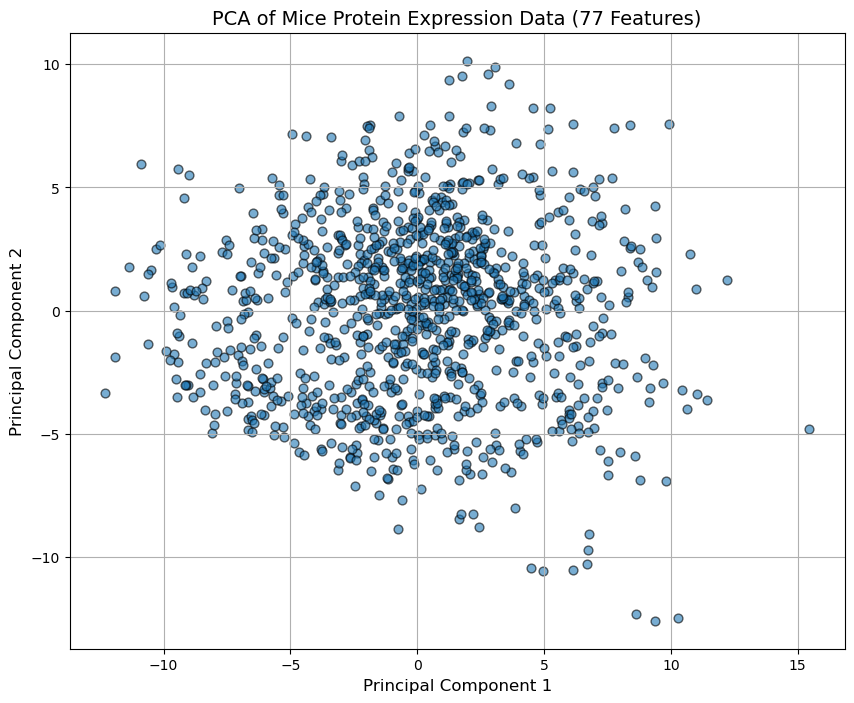

In [75]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_filtered)

# Step 2: Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 3: PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Visualize

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=40, alpha=0.6, edgecolors='k')
plt.title('PCA of Mice Protein Expression Data (77 Features)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True)
plt.show()



In [77]:
from sklearn.mixture import GaussianMixture

# Number of clusters (can try other values)
n_clusters = 8

# Apply GMM
gmm = GaussianMixture(n_components=n_clusters, random_state=0)
gmm_labels = gmm.fit_predict(X_scaled)


In [79]:
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)


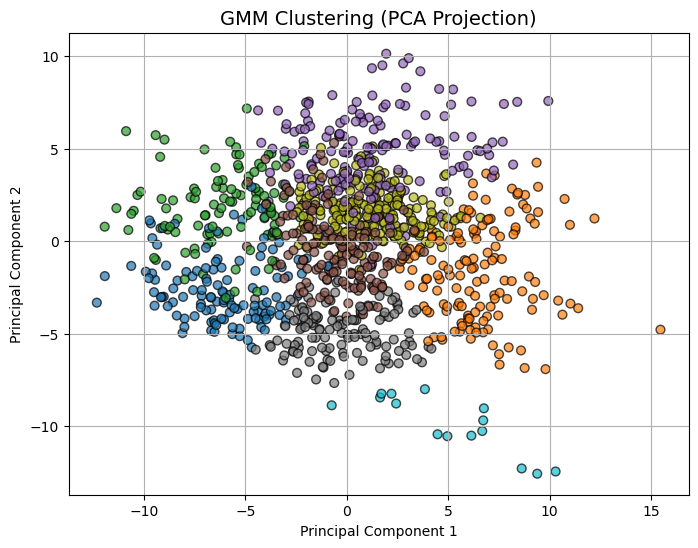

In [81]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='tab10', s=40, alpha=0.7, edgecolors='k')
plt.title('GMM Clustering (PCA Projection)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


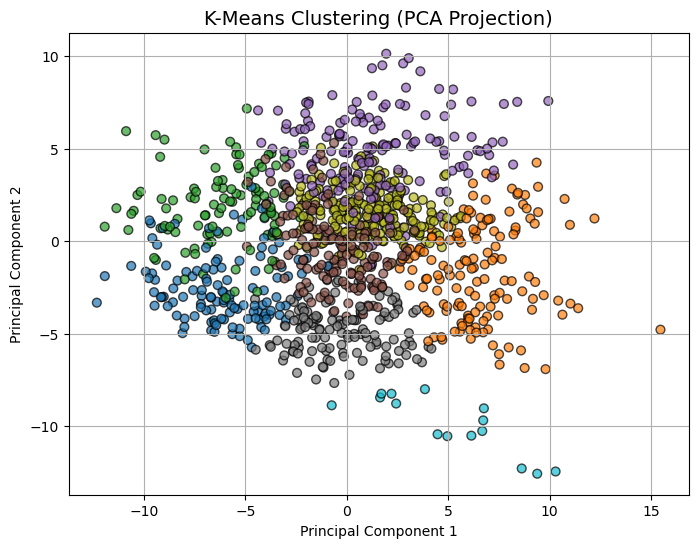

In [83]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', s=40, alpha=0.7, edgecolors='k')
plt.title('K-Means Clustering (PCA Projection)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


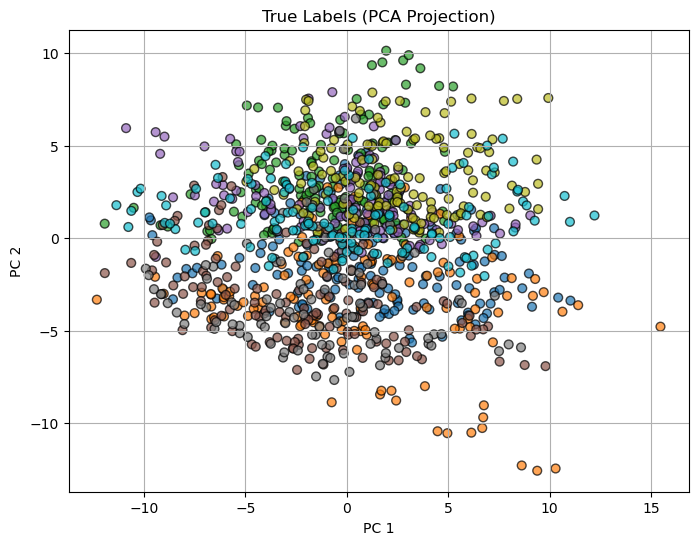

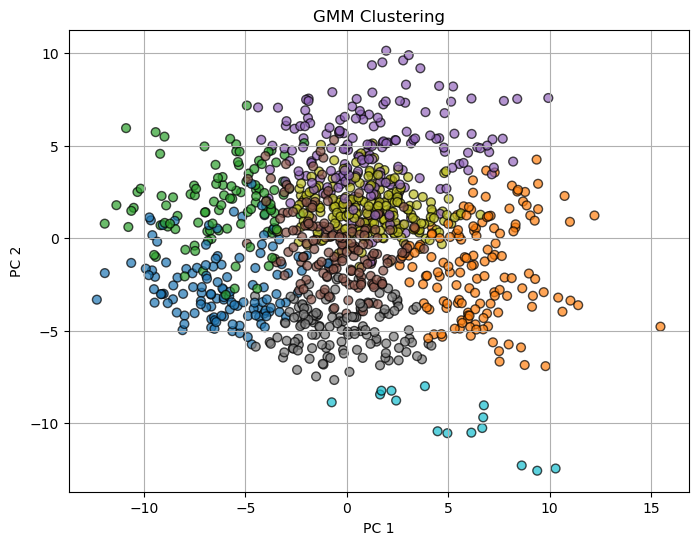

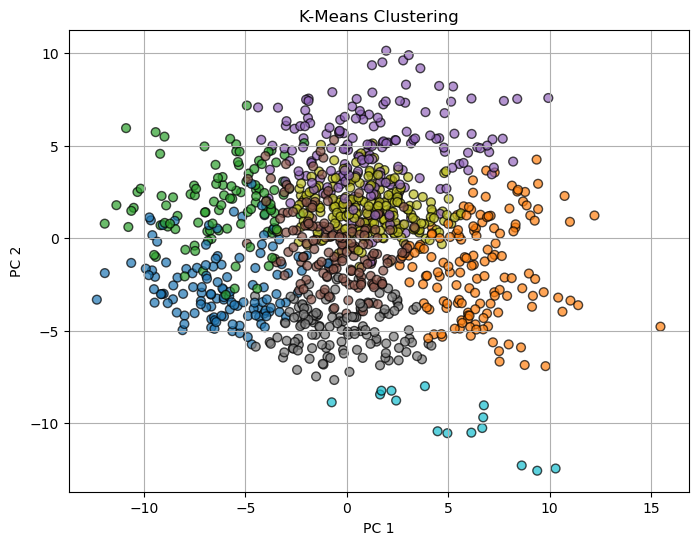

Adjusted Rand Index (GMM): 0.132
Adjusted Rand Index (K-Means): 0.131


In [89]:
from sklearn.preprocessing import LabelEncoder

# Encode string labels if needed
le = LabelEncoder()
y_encoded = le.fit_transform(y['class'].values)  # Replace 'class' with the actual column name


# Plot with true labels
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='tab10', s=40, alpha=0.7, edgecolors='k')
plt.title('True Labels (PCA Projection)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True)
plt.show()

# Plot GMM
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='tab10', s=40, alpha=0.7, edgecolors='k')
plt.title('GMM Clustering')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True)
plt.show()

# Plot KMeans
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', s=40, alpha=0.7, edgecolors='k')
plt.title('K-Means Clustering')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True)
plt.show()
from sklearn.metrics import adjusted_rand_score

ari_gmm = adjusted_rand_score(y_encoded, gmm_labels)
ari_kmeans = adjusted_rand_score(y_encoded, kmeans_labels)

print(f"Adjusted Rand Index (GMM): {ari_gmm:.3f}")
print(f"Adjusted Rand Index (K-Means): {ari_kmeans:.3f}")



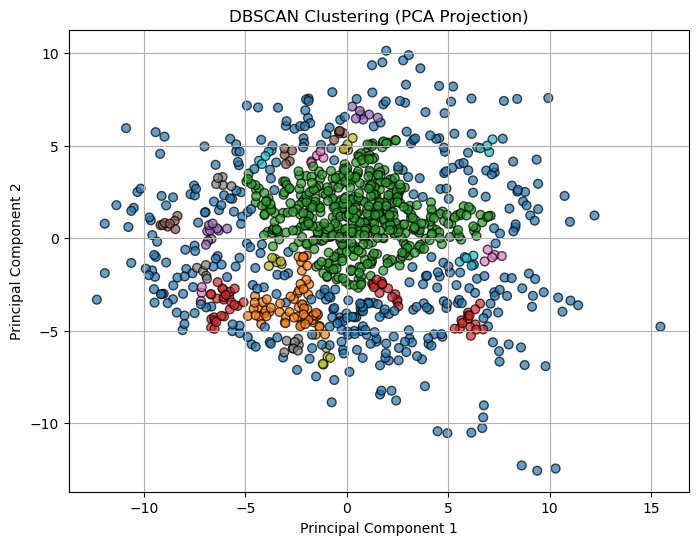

In [91]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

# Plot DBSCAN clustering results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', s=40, alpha=0.7, edgecolors='k')
plt.title('DBSCAN Clustering (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


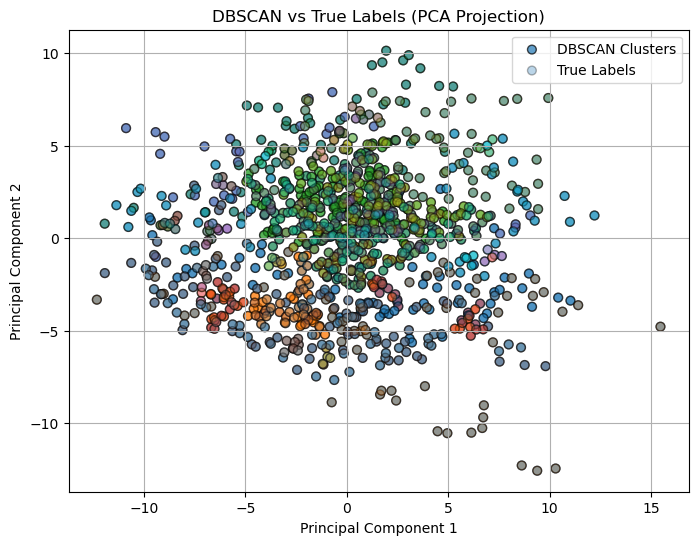

In [93]:
# Plot DBSCAN results with true labels for comparison
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', s=40, alpha=0.7, edgecolors='k', label='DBSCAN Clusters')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='tab10', s=40, alpha=0.3, edgecolors='k', label='True Labels')
plt.title('DBSCAN vs True Labels (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()


In [99]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=n_classes, random_state=42)
gmm_labels = gmm.fit_predict(X_train)

# Fit K-Means clustering
kmeans = KMeans(n_clusters=n_classes, random_state=42)
kmeans_labels = kmeans.fit_predict(X_train)

# Fit DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_train)

# Flatten y_train to 1D by converting it to a numpy array
y_train_flat = y_train.values.ravel()

# Compute ARI scores
ari_gmm = adjusted_rand_score(y_train_flat, gmm_labels)
ari_kmeans = adjusted_rand_score(y_train_flat, kmeans_labels)
ari_dbscan = adjusted_rand_score(y_train_flat, dbscan_labels)

# Print ARI scores
print(f"ARI for GMM: {ari_gmm:.4f}")
print(f"ARI for K-Means: {ari_kmeans:.4f}")
print(f"ARI for DBSCAN: {ari_dbscan:.4f}")




C:\Users\evgenija\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\evgenija\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


ARI for GMM: 0.0891
ARI for K-Means: 0.0865
ARI for DBSCAN: 0.0138
